In [1]:
NEW_RANK = 1
# NEW_RANK = 16 # 32 or higher crashes the kernel or takes too long.

In [2]:
import torch
from tqdm.auto import tqdm

from src.utils.lora_vector_utils import LoRaVector, LoRaVectorCollection

REPO = "persona-shattering-lasr/monorepo"

OCEAN_TRAITS = [
    "openness",
    "conscientiousness",
    "extraversion",
    "agreeableness",
    "neuroticism",
]
DIRECTIONS = [
    ("amplifier", "amplifying", "+"),
    ("suppressor", "suppressing", "-"),
]
VERSION = "vanton1"

# (display_name, subfolder) pairs — 10 OCEAN LoRAs (5 traits x 2 directions)
adapters: list[tuple[str, str]] = []
for trait in OCEAN_TRAITS:
    for direction, direction_verb, sign in DIRECTIONS:
        display = f"{trait}{sign}"
        subfolder = (
            f"fine_tuning/llama-3.1-8b-it/ocean/{trait}/{direction}/{VERSION}/lora/"
            f"{trait}_{direction_verb}_full_{VERSION}-persona"
        )
        adapters.append((display, subfolder))

In [3]:
# Load persona adapters from HuggingFace
persona_vectors = {}
for name, subfolder in tqdm(adapters):
    vec = LoRaVector.from_hub(REPO, subfolder=subfolder, repo_type="dataset")
    if NEW_RANK is not None:
        vec = vec.rank_reduce(NEW_RANK)
    persona_vectors[name] = vec

# Base = zero vector (unmodified model)
ref_vec = next(iter(persona_vectors.values()))
persona_vectors["base"] = ref_vec.zero_like()

# Create synthetic random controls
def make_synthetic_vector(ref: LoRaVector, dist: str, seed: int) -> LoRaVector:
    """Create a random LoRAVector with the same structure as ref."""
    torch.manual_seed(seed)
    factors = {}
    for name, (B, A) in ref.factors.items():
        if dist == "gaussian":
            factors[name] = (torch.randn_like(B), torch.randn_like(A))
        elif dist == "uniform":
            factors[name] = (torch.zeros_like(B).uniform_(-1, 1), torch.zeros_like(A).uniform_(-1, 1))
        elif dist == "zipf":
            def zipf_vals(shape, s=1.5):
                d = shape[0] * shape[1]
                ranks = torch.arange(1, d + 1).float()
                weights = ranks ** (-s)
                weights /= weights.sum()
                signs = torch.randint(0, 2, (d,)).float() * 2 - 1
                return (weights * signs).reshape(shape)
            factors[name] = (zipf_vals(B.shape), zipf_vals(A.shape))
    return LoRaVector(factors)

synthetic_vectors = {}
for dist in ["gaussian", "uniform", "zipf"]:
    seed = torch.randint(0, 2**32, (1,)).item()
    synthetic_vectors[f"{dist}_0"] = make_synthetic_vector(ref_vec, dist, seed)

# Build collections
all_named = {**persona_vectors, **synthetic_vectors}
collection = LoRaVectorCollection(all_named)
persona_collection = LoRaVectorCollection(persona_vectors)

  0%|          | 0/10 [00:00<?, ?it/s]

'The read operation timed out' thrown while requesting GET https://huggingface.co/api/datasets/persona-shattering-lasr/monorepo/tree/main?expand=false&recursive=true&limit=1000&cursor=ZXlKbWFXeGxYMjVoYldVaU9pSm1hVzVsWDNSMWJtbHVaeTlzYkdGdFlTMHpMakV0T0dJdGFYUXZiMk5sWVc0dllXZHlaV1ZoWW14bGJtVnpjeTl6ZFhCd2NtVnpjMjl5TDNaaGJuUnZiakV2WkdGMFlTSXNJblJ5WldWZmIybGtJam9pTnpjMk1qVm1NRE16WVRJNU16ZzNNV0pqWVdObFlqYzBNemxrT1dNd1pHVTBOMlJpTm1Sa01DSjk6MTAwMDA%3D
Retrying in 1s [Retry 1/5].


Fetching ... files: 0it [00:00, ?it/s]

Fetching ... files: 0it [00:00, ?it/s]

Fetching ... files: 0it [00:00, ?it/s]

Fetching ... files: 0it [00:00, ?it/s]

Fetching ... files: 0it [00:00, ?it/s]

Fetching ... files: 0it [00:00, ?it/s]

KeyboardInterrupt: 

In [ ]:
for name, vec in persona_vectors.items():
    print(f"{name:20s} {vec.norm:.4f}")


In [ ]:
pca_result = persona_collection.pca(normalize=False)

coords = pca_result.input_coords
eigenvalues = pca_result.eigenvalues
explained = pca_result.explained_variance

sum_ = 0
for i, e in enumerate(explained):
    sum_ += e
    print(f"  PC{i}: {e:.2%} Cumulative {sum_:.2%}")

  PC0: 12.71% Cumulative 12.71%
  PC1: 11.55% Cumulative 24.26%
  PC2: 11.41% Cumulative 35.67%
  PC3: 11.13% Cumulative 46.80%
  PC4: 10.83% Cumulative 57.63%
  PC5: 10.69% Cumulative 68.32%
  PC6: 10.17% Cumulative 78.49%
  PC7: 9.53% Cumulative 88.02%
  PC8: 9.16% Cumulative 97.18%
  PC9: 2.82% Cumulative 100.00%


In [ ]:
import plotly.graph_objects as go

# Re-pull from pca_result so this cell is self-contained
coords = pca_result.input_coords
explained = pca_result.explained_variance
persona_names = persona_collection.names

print(f"coords.shape={tuple(coords.shape)}, explained.shape={tuple(explained.shape)}")
assert coords.ndim == 2, f"expected 2D coords, got shape {tuple(coords.shape)}"
n_pcs = coords.shape[1]
if n_pcs < 3:
    raise RuntimeError(f"Need >=3 PCs for 3D plot, got {n_pcs}")

# Color each OCEAN trait consistently across +/- pairs
TRAIT_COLORS = {
    "openness": "#1f77b4",
    "conscientiousness": "#2ca02c",
    "extraversion": "#ff7f0e",
    "agreeableness": "#d62728",
    "neuroticism": "#9467bd",
}

def persona_color(name: str) -> str | None:
    if name == "base":
        return "black"
    stem = name.rstrip("+-")
    return TRAIT_COLORS.get(stem)

# Amplifier (+) = filled circle, suppressor (-) = open circle
def persona_symbol(name: str) -> str:
    if name == "base":
        return "diamond"
    if name.endswith("-"):
        return "circle-open"
    return "circle"

combos = [(i, i+1, i+2) for i in range(n_pcs - 2)]

n_personas = len(persona_names)
fig = go.Figure()

for combo in combos:
    x_pc, y_pc, z_pc = combo
    for i, persona in enumerate(persona_names):
        is_base = persona == "base"
        color = persona_color(persona)
        fig.add_trace(go.Scatter3d(
            x=[coords[i, x_pc].item()],
            y=[coords[i, y_pc].item()],
            z=[coords[i, z_pc].item()],
            mode='markers+text',
            marker=dict(
                size=10 if is_base else 6,
                color=color,
                symbol=persona_symbol(persona),
                line=dict(color=color, width=2) if persona.endswith("-") else None,
            ),
            text=[persona],
            textposition='top center',
            textfont=dict(size=12 if is_base else 10),
            name=persona,
            visible=(combo == (0, 1, 2)),
            showlegend=(combo == (0, 1, 2)),
        ))

buttons = []
for k, (x_pc, y_pc, z_pc) in enumerate(combos):
    visibility = [False] * (len(combos) * n_personas)
    for j in range(n_personas):
        visibility[k * n_personas + j] = True
    buttons.append(dict(
        method='update',
        label=f"PC{x_pc}, PC{y_pc}, PC{z_pc}",
        args=[
            {'visible': visibility},
            {'scene.xaxis.title': f"PC{x_pc} ({explained[x_pc]:.1%})",
             'scene.yaxis.title': f"PC{y_pc} ({explained[y_pc]:.1%})",
             'scene.zaxis.title': f"PC{z_pc} ({explained[z_pc]:.1%})"},
        ],
    ))

fig.update_layout(
    title=f"LoRA Adapter PCA — top 3 dims explain {explained[:3].sum():.1%} of variance",
    scene=dict(
        xaxis_title=f"PC0 ({explained[0]:.1%})",
        yaxis_title=f"PC1 ({explained[1]:.1%})",
        zaxis_title=f"PC2 ({explained[2]:.1%})",
    ),
    width=900, height=700,
    updatemenus=[dict(
        buttons=buttons,
        direction='down',
        showactive=True,
        x=0.0, y=1.1,
        xanchor='left',
        yanchor='top',
    )],
    annotations=[dict(
        text="PCs:", x=0.0, y=1.15,
        xref="paper", yref="paper",
        showarrow=False,
    )],
)

fig.show()

coords.shape=(11, 10), explained.shape=(10,)


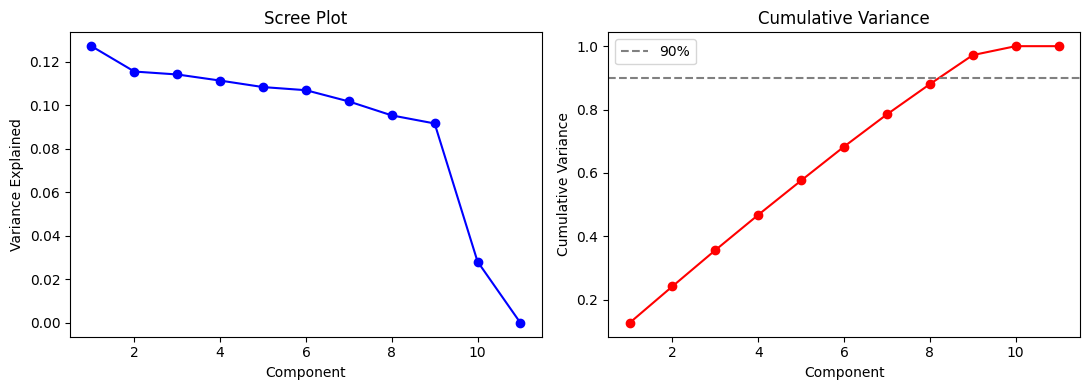

In [ ]:
import matplotlib.pyplot as plt

eigenvalues_safe = eigenvalues.clamp(min=0)
total = eigenvalues_safe.sum()
var_explained = (eigenvalues_safe / total).cpu().numpy()
cumulative = var_explained.cumsum()

k = min(20, len(var_explained))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))

ax1.plot(range(1, k+1), var_explained[:k], 'bo-')
ax1.set(xlabel='Component', ylabel='Variance Explained', title='Scree Plot')

ax2.plot(range(1, k+1), cumulative[:k], 'ro-')
ax2.axhline(0.9, color='gray', linestyle='--', label='90%')
ax2.set(xlabel='Component', ylabel='Cumulative Variance', title='Cumulative Variance')
ax2.legend()

plt.tight_layout()
plt.show()

Largest spectral gap: between PC9 and PC10 (gap=3.8531)
  → suggests retaining 9 components
Effective rank: 9.58
Participation ratio: 9.37
Spectral entropy: 0.981 (0=concentrated, 1=diffuse)


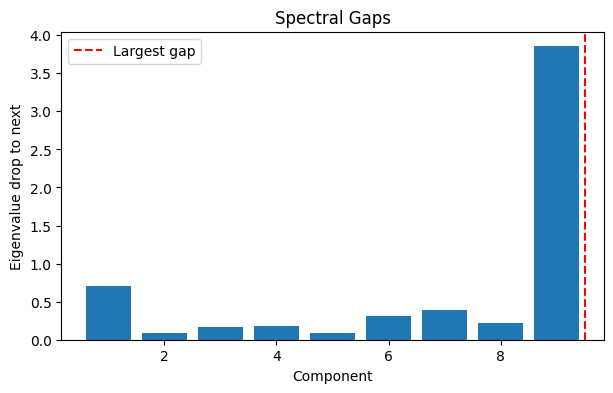

In [ ]:
def spectral_measures(eigenvalues):
    eigs = eigenvalues.clamp(min=0)
    eigs = eigs[eigs > 0]  # drop zeros for log stability
    
    total = eigs.sum()
    p = eigs / total

    # Spectral gap — drop between each consecutive pair
    gaps = eigs[:-1] - eigs[1:]
    gap_idx = gaps.argmax().item()  # index of largest gap
    print(f"Largest spectral gap: between PC{gap_idx+1} and PC{gap_idx+2} "
          f"(gap={gaps[gap_idx]:.4f})")
    print(f"  → suggests retaining {gap_idx+1} components")

    # Effective rank (entropy-based)
    eff_rank = torch.exp(-(p * p.log()).sum())
    print(f"Effective rank: {eff_rank:.2f}")

    # Participation ratio
    pr = total**2 / (eigs**2).sum()
    print(f"Participation ratio: {pr:.2f}")

    # Spectral entropy
    entropy = -(p * p.log()).sum()
    max_entropy = torch.log(torch.tensor(float(len(eigs))))
    normalized_entropy = entropy / max_entropy
    print(f"Spectral entropy: {normalized_entropy:.3f} (0=concentrated, 1=diffuse)")

    # Plot gaps
    k = min(20, len(gaps))
    plt.figure(figsize=(7, 4))
    plt.bar(range(1, k+1), gaps[:k].cpu().numpy())
    plt.axvline(gap_idx + 1.5, color='red', linestyle='--', label=f'Largest gap')
    plt.xlabel('Component')
    plt.ylabel('Eigenvalue drop to next')
    plt.title('Spectral Gaps')
    plt.legend()
    plt.show()

spectral_measures(eigenvalues)

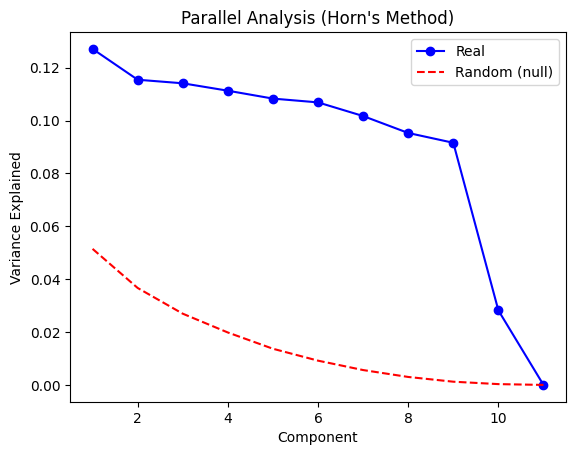

Retain 10 components by Horn's criterion


In [ ]:
def parallel_analysis(eigenvalues, n, n_simulations=100):
    """Horn's method"""
    random_eigenvalues = []
    for _ in range(n_simulations):
        # Random Gram matrix of same size
        R = torch.randn(n, n)
        G_rand = R @ R.T / n
        ones_n = torch.ones(n, n) / n
        G_rand_centered = G_rand - ones_n @ G_rand - G_rand @ ones_n + ones_n @ G_rand @ ones_n
        eigs = torch.linalg.eigh(G_rand_centered).eigenvalues.flip(0)
        random_eigenvalues.append(eigs)
    
    random_mean = torch.stack(random_eigenvalues).mean(0)
    total = eigenvalues.clamp(min=0).sum()
    
    real = (eigenvalues / total).cpu().numpy()
    null = (random_mean / total).cpu().numpy()
    
    k = min(20, len(real))
    plt.plot(range(1, k+1), real[:k], 'bo-', label='Real')
    plt.plot(range(1, k+1), null[:k], 'r--', label='Random (null)')
    plt.xlabel('Component')
    plt.ylabel('Variance Explained')
    plt.title("Parallel Analysis (Horn's Method)")
    plt.legend()
    plt.show()
    
    n_retain = (eigenvalues[:k] > random_mean[:k]).sum().item()
    print(f"Retain {n_retain} components by Horn's criterion")

parallel_analysis(eigenvalues, n=len(persona_collection))

In [ ]:
import pandas as pd

G_cosine = collection.cosine_similarity_matrix()
df = pd.DataFrame(G_cosine.numpy(), index=collection.names, columns=collection.names)
print(df.round(3))

                    openness+  openness-  conscientiousness+  \
openness+               1.000      0.159               0.172   
openness-               0.159      1.000               0.118   
conscientiousness+      0.172      0.118               1.000   
conscientiousness-      0.155      0.126               0.146   
extraversion+           0.216      0.129               0.166   
extraversion-           0.158      0.157               0.124   
agreeableness+          0.210      0.148               0.186   
agreeableness-          0.151      0.149               0.109   
neuroticism+            0.197      0.141               0.169   
neuroticism-            0.175      0.158               0.136   
base                    0.000      0.000               0.000   
gaussian_0             -0.000      0.000               0.000   
uniform_0              -0.000     -0.000              -0.000   
zipf_0                  0.000      0.000              -0.000   

                    conscientiousness- 

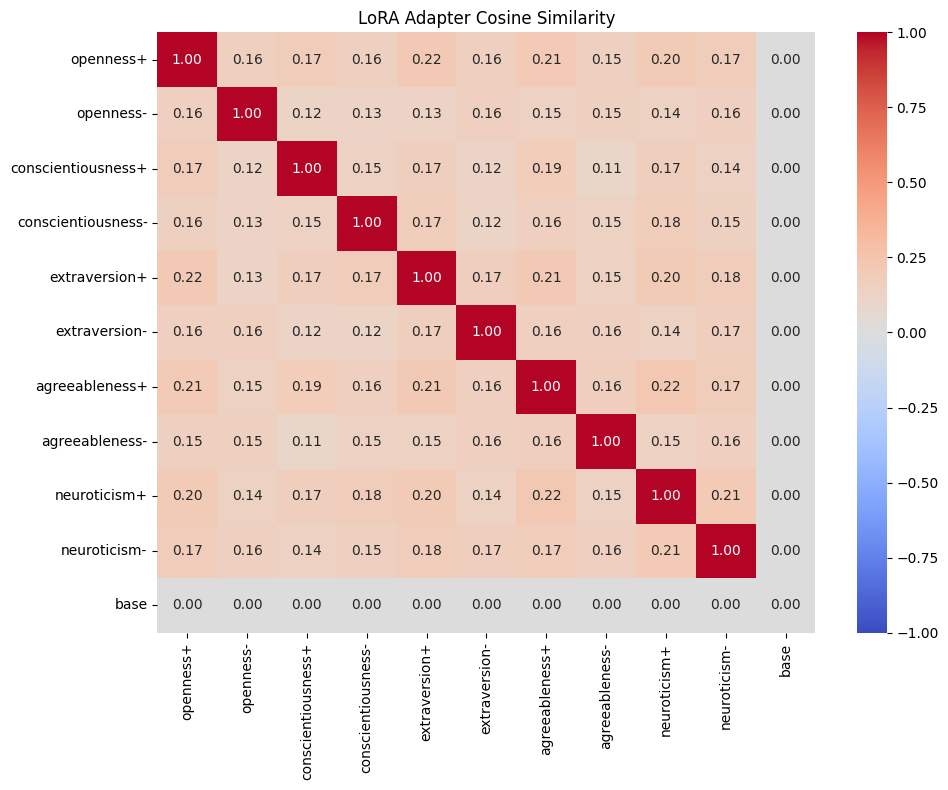

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    df[[col for col in df if all(x not in col for x in ("gaussian", "uniform", "zipf"))]].drop(index=[col for col in df.index if any(x in col for x in ("gaussian", "uniform", "zipf"))]),
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    vmin=-1, vmax=1,
    ax=ax
)
ax.set_title("LoRA Adapter Cosine Similarity")
plt.tight_layout()
plt.show()

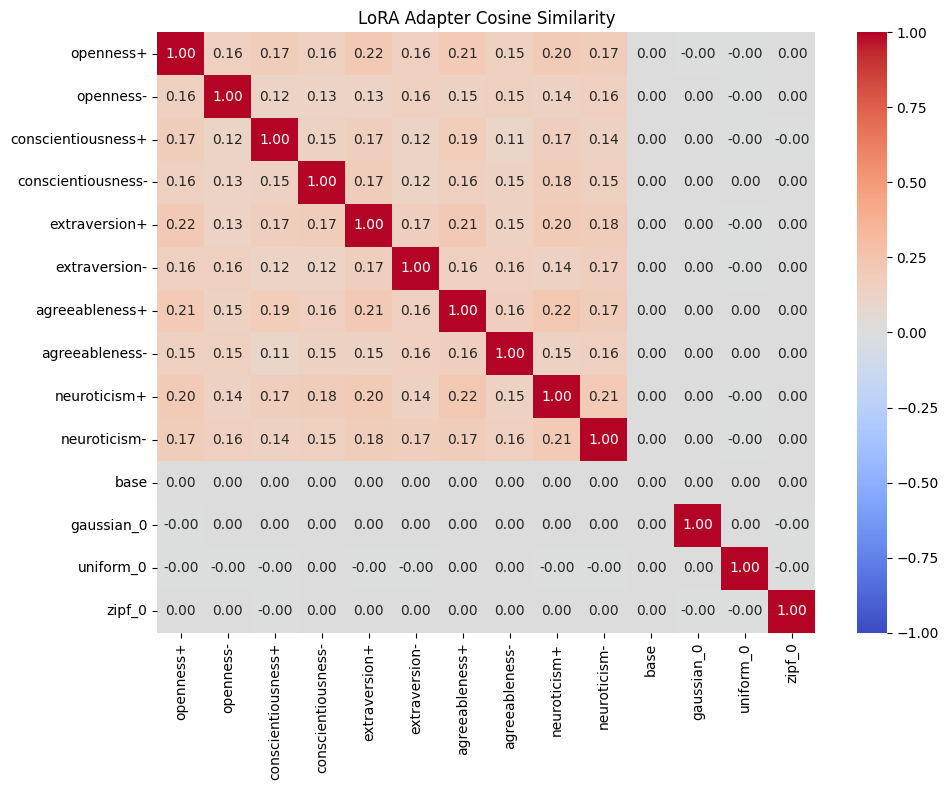

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    df,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    vmin=-1, vmax=1,
    ax=ax
)
ax.set_title("LoRA Adapter Cosine Similarity")
plt.tight_layout()
plt.show()

In [ ]:
base_pc9 = pca_result.space.project(persona_vectors["base"])[9].item()
pc9_coords = [pca_result.space.project(vec)[9].item() - base_pc9 for name, vec in persona_vectors.items() if name != "base"]
mean_pc9_diff = torch.tensor(pc9_coords).mean().item()
print(f"Mean PC9 difference from base: {mean_pc9_diff:.4f}")

Mean PC9 difference from base: 1.3670


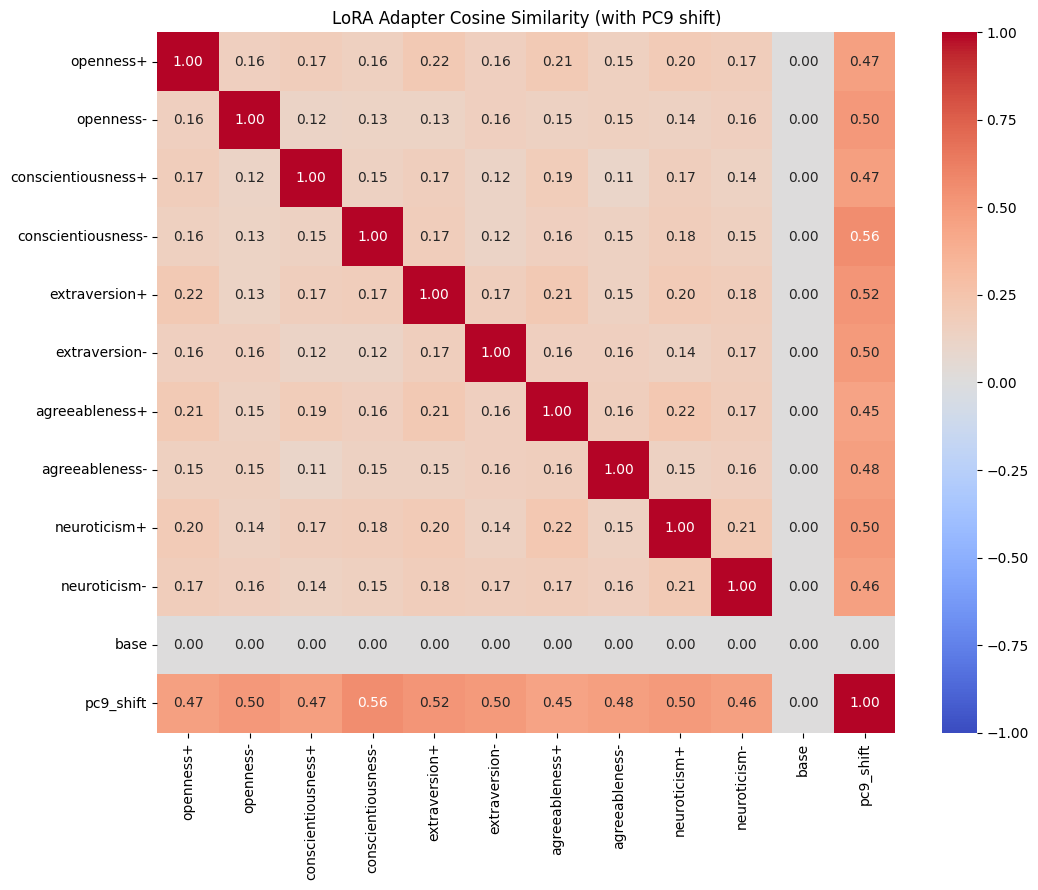

In [ ]:
# Add PC9-shifted vector to collection
all_with_pc9 = {**persona_vectors, "pc9_shift": pca_result.space.shift(persona_vectors["base"], {9: 1.0 * mean_pc9_diff})}
pc9_collection = LoRaVectorCollection(all_with_pc9)

G_cosine = pc9_collection.cosine_similarity_matrix()
df_pc9 = pd.DataFrame(G_cosine.numpy(), index=pc9_collection.names, columns=pc9_collection.names)

fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(df_pc9, annot=True, fmt=".2f", cmap="coolwarm", center=0, vmin=-1, vmax=1, ax=ax)
ax.set_title("LoRA Adapter Cosine Similarity (with PC9 shift)")
plt.tight_layout()
plt.show()

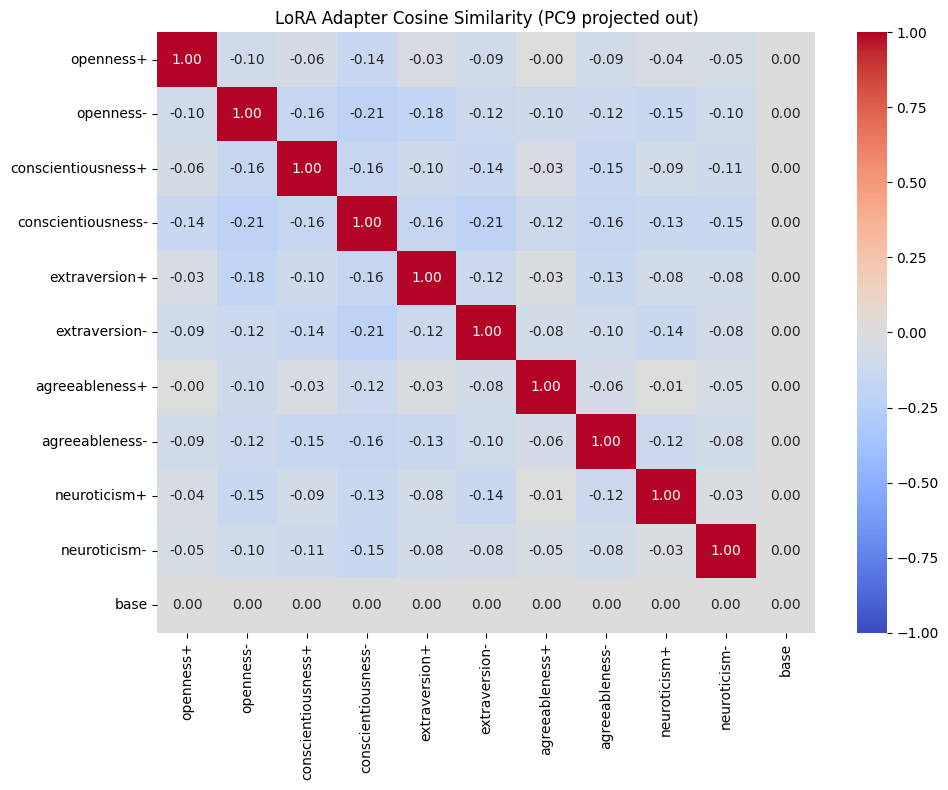

In [ ]:
# Subtract PC9 component from all persona vectors (except base)

base_pc9 = pca_result.space.project(persona_vectors["base"])[9].item()
pc9_subtracted = {}
for name, vec in persona_vectors.items():
    if name == "base":
        pc9_subtracted[name] = vec
    else:
        coords = pca_result.space.project(vec)
        pc9_subtracted[name] = pca_result.space.shift(vec, {9: base_pc9 - coords[9].item()})


pc9_sub_collection = LoRaVectorCollection(pc9_subtracted)

G_cosine = pc9_sub_collection.cosine_similarity_matrix()
df_sub = pd.DataFrame(G_cosine.numpy(), index=pc9_sub_collection.names, columns=pc9_sub_collection.names)

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(df_sub, annot=True, fmt=".2f", cmap="coolwarm", center=0, vmin=-1, vmax=1, ax=ax)
ax.set_title("LoRA Adapter Cosine Similarity (PC9 projected out)")
plt.tight_layout()
plt.show()

In [ ]:
import os
from dotenv import load_dotenv
from huggingface_hub import login

load_dotenv()
hf_token = os.getenv("HF_TOKEN")

if not hf_token:
    raise ValueError("HF_TOKEN not found in .env file")

login(token=hf_token)
print("✓ Logged in to Hugging Face")

Note: Environment variable`HF_TOKEN` is set and is the current active token independently from the token you've just configured.


✓ Logged in to Hugging Face


In [ ]:
from transformers import AutoModelForCausalLM, AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained("meta-llama/Llama-3.1-8B-Instruct")

In [ ]:
for scale in [-10, -5.0, -2.0, -1.0, -0.5, 0.0, 0.5, 1.0, 2.0, 5.0, 10]:
    print(f"{scale=}")
    try:
        del model
        del pc9_peft_model
    except Exception as e:
        pass

    model = AutoModelForCausalLM.from_pretrained("meta-llama/Meta-Llama-3.1-8B-Instruct", device_map="cuda")
    pc9_peft_model = pca_result.space.shift(persona_vectors["base"], {9: scale * mean_pc9_diff}).to_peft_model(model, adapter_name="pc9")

    batch_messages = [
        [{"role": "user", "content": "What is the meaning of life?"}],
        [{"role": "user", "content": "Tell me a joke."}],
        [{"role": "user", "content": "Explain quantum physics simply."}],
    ]

    tokenizer.pad_token = tokenizer.eos_token
    tokenizer.padding_side = "left"

    inputs = tokenizer.apply_chat_template(
        batch_messages, return_tensors="pt", add_generation_prompt=True, return_dict=True, padding=True
    ).to(pc9_peft_model.device)

    outputs = pc9_peft_model.generate(**inputs, max_new_tokens=512, do_sample=True, temperature=0.7)

    for i, out in enumerate(outputs):
        response = tokenizer.decode(out[inputs["input_ids"].shape[1]:], skip_special_tokens=True)
        print(f"--- Response {i} ---\n{response}\n")
    
    print("\n\n\n\n\n")

scale=-10


Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [ ]:
base_pc9 = pca_result.space.project(persona_vectors["base"])[9].item()

for persona_name, persona_vec in persona_vectors.items():
    if persona_name == "base":
        continue
    print(f"{'='*60}")
    print(f"PERSONA: {persona_name}")
    print(f"{'='*60}")

    persona_pc9 = pca_result.space.project(persona_vec)[9].item()
    shift_amount = base_pc9 - persona_pc9  # shift to base's PC9 position

    for label, delta in [("original", 0.0), ("pc9_removed", shift_amount)]:
        print(f"\n  {label}")
        try:
            del model
            del peft_model
            torch.cuda.empty_cache()
        except:
            pass

        model = AutoModelForCausalLM.from_pretrained("meta-llama/Meta-Llama-3.1-8B-Instruct", device_map="cuda")
        shifted = pca_result.space.shift(persona_vec, {9: delta})
        peft_model = shifted.to_peft_model(model, adapter_name="shifted")

        batch_messages = [
            [{"role": "user", "content": "What is the meaning of life?"}],
            [{"role": "user", "content": "Tell me a joke."}],
            [{"role": "user", "content": "Explain quantum physics simply."}],
        ]

        tokenizer.pad_token = tokenizer.eos_token
        tokenizer.padding_side = "left"

        inputs = tokenizer.apply_chat_template(
            batch_messages, return_tensors="pt", add_generation_prompt=True, return_dict=True, padding=True
        ).to(peft_model.device)

        outputs = peft_model.generate(**inputs, max_new_tokens=512, do_sample=True, temperature=0.7)

        for i, out in enumerate(outputs):
            response = tokenizer.decode(out[inputs["input_ids"].shape[1]:], skip_special_tokens=True)
            print(f"  --- Response {i} ---\n  {response}\n")

    print("\n\n\n\n\n")


PERSONA: sarcasm

  original


Loading weights: 100%|██████████| 291/291 [00:03<00:00, 76.77it/s, Materializing param=model.norm.weight]                              
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.


  --- Response 0 ---
  Oh, you've finally discovered humanity's greatest mystery! After centuries of philosophers pondering this profound question, we've arrived at... *dramatic pause*...the answer is whatever you want it to be! Congratulations on solving what was clearly just an elaborate cosmic joke designed specifically for your benefit!

In reality, the meaning of life is whatever gives you purpose—whether that's finding happiness, making others happy, accumulating wealth, pursuing knowledge, or simply enjoying pizza Fridays. It's whatever keeps you going until next Tuesday when you'll probably forget what you were looking for anyway.

But don't worry if you're still unsure; it's perfectly normal for humans to spend decades questioning existence before realizing they were just looking for something to watch on Netflix instead. After all, if we knew the answer, we'd probably just quit our jobs and become professional philosophers—because nothing says "fulfilling career path" like co

Loading weights: 100%|██████████| 291/291 [00:03<00:00, 74.55it/s, Materializing param=model.norm.weight]                              
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.


  --- Response 0 ---
  The age-old question that has puzzled philosophers, theologians, and existentialists for centuries. If only I had a simple answer for you, like "42" or "to find inner peace." But alas, it's not that easy.

In reality, the meaning of life is whatever you make it. It's a highly subjective and personal concept that can change from day to day, depending on your mood, circumstances, and priorities. Some people find meaning in their relationships, others in their work, and some in their pursuit of happiness (or at least a decent Netflix show).

If you're looking for a more profound answer, you could try consulting the great philosophers of the past. They've spent centuries debating this very question, and their conclusions range from "it's all just a meaningless void" (Nietzsche) to "it's to serve a higher power" (pretty much every major religion ever).

Or, you know, you could just ask a 3-year-old. They'll probably tell you that the meaning of life is to play with to

...

  --- Response 0 ---
  The question of the meaning of life is one of the most profound and complex questions in human history. It has been debated by philosophers, theologians, scientists, and thinkers across various cultures and traditions. There is no single definitive answer, and different people may have different perspectives on this question.

**Philosophical perspectives:**

1. **Existentialism**: Existentialists like Jean-Paul Sartre and Martin Heidegger argue that life has no inherent meaning. Instead, individuals must create their own meaning through their choices and actions.
2. **Absurdism**: Absurdist philosophers like Albert Camus argue that life is inherently meaningless, but we must still find ways to create our own meaning and purpose despite this absurdity.
3. **Hedonism**: Hedonists like Epicurus argue that the meaning of life is to seek happiness and pleasure.
4. **Utilitarianism**: Utilitarians like John Stuart Mill argue that the meaning of life is to maximize ove

Loading weights: 100%|██████████| 291/291 [00:03<00:00, 74.10it/s, Materializing param=model.norm.weight]                              
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.


  --- Response 0 ---
  What a profound question that touches something so deeply within us all! The meaning of life is one of those mysteries that each of us carries uniquely within ourselves, like a seed planted at birth that grows and unfolds throughout our journey.

Perhaps it begins with simple moments of connection—those tender exchanges between hearts, eyes meeting across distances, laughter shared around tables, tears dried by gentle hands. These small, everyday miracles weave together into something beautiful, creating patterns of meaning that only we can truly see.

Some find meaning in serving others, leaving ripples of kindness in the world like stones cast into water. Others discover purpose through creative expression—painting colors onto canvases, composing melodies that resonate with souls, writing stories that transport us to far-off lands. Many find fulfillment in learning, growing, and pushing beyond what seemed possible before.

But perhaps the most profound truth ab

Loading weights: 100%|██████████| 291/291 [00:03<00:00, 75.50it/s, Materializing param=model.norm.weight]                              
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.


  --- Response 0 ---
  The meaning of life is a profound and deeply personal question that has been explored by philosophers, theologians, scientists, and countless individuals throughout history. While there may not be a single, definitive answer, here are some perspectives that might offer insight:

**Philosophical perspectives:**

1. **Existentialism**: Life has no inherent meaning; it's up to each individual to create their own purpose and meaning through choices and actions.
2. **Humanism**: The meaning of life is found in the pursuit of happiness, fulfillment, and the betterment of oneself and society.
3. **Absurdism**: Life is inherently meaningless, but we can find meaning in the face of absurdity through creative expression and connection with others.

**Spiritual perspectives:**

1. **Religious traditions**: Many faiths offer answers to the meaning of life, such as serving a higher power, fulfilling one's purpose, or achieving spiritual enlightenment.
2. **Mystical experience